In [1]:
import numpy as np
import pandas as pd
import os, subprocess, vcf, itertools

Sample_ID = "230323"  # 230323	chr3:189868682  G>A와  chr18:46084341 을 지움

def VAF_CALC ( d ):
    if d.data.AF == None:
        return 0
    else:
        if d.data.GT in [ "0/1", "0|1" ]:
            return d.data.AD [1] / d.data.DP
        elif d.data.GT in [ "1/0", "1|0" ]:
            return d.data.AD [0] / d.data.DP
        else:
            return 0

def MAKE_METEL_INPUT ( row_i, col_i, METEL_INPUT_TSV):
    output_file = open ( METEL_INPUT_TSV, "w")

    vcf_reader = vcf.Reader( open ( "/data/project/Meningioma/04.mutect/09.multiple/" + Sample_ID + "/merged.vcf", "r") )
    for record in vcf_reader: 
        vaf_row = VAF_CALC ( record.samples [row_i] )
        vaf_col = VAF_CALC  ( record.samples [col_i] ) 
        if (vaf_row == 0) & (vaf_col == 0):
            continue

        if record.CHROM + ":" + str (record.POS) in ( [ "chr22:29671847", "chr22:29636758", "chr22:29661335" ]  ):
            print ( "{}\tNF2\t.\t.\t{}\t{}".format ( Sample_ID, vaf_row, vaf_col), file = output_file )
        else:
            print ( "{}\t{}\t.\t.\t{}\t{}".format ( Sample_ID, record.CHROM + ":" + str (record.POS), vaf_row, vaf_col), file = output_file )

    output_file.close()


##############################################################################################################

vcf_reader = vcf.Reader( open ( "/data/project/Meningioma/04.mutect/09.multiple/" + Sample_ID + "/merged.vcf", "r") )
samplenames = vcf_reader.samples
print (samplenames)
os.makedirs ( "/data/project/Meningioma/04.mutect/11.MeTel/" + Sample_ID + "/01.Input" , exist_ok = True)
os.makedirs ( "/data/project/Meningioma/04.mutect/11.MeTel/" + Sample_ID + "/02.Output" , exist_ok = True)


i_li = []
for i, samplename in enumerate (samplenames):
    if  ("Blood" in samplename)  |  ("Falx_2" in samplename):
        continue
    i_li.append ( i )

# Classification score에 대해 df 를 선언
df = pd.DataFrame ( np.zeros (  ( len(i_li), len(i_li) )  ), columns = [ samplenames[i] for i in i_li], index = [ samplenames[i] for i in i_li] )


for i1, row_i in enumerate ( i_li ) :
    for i2, col_i in enumerate ( i_li):
        if row_i == col_i:
            continue
        print ( samplenames[row_i], samplenames [col_i]  )

        METEL_INPUT_TSV = "/data/project/Meningioma/04.mutect/11.MeTel/" + str (Sample_ID)+ "/01.Input/" + samplenames[row_i] + "_and_" + samplenames[col_i] + ".tsv"
        #MAKE_METEL_INPUT ( row_i, col_i , METEL_INPUT_TSV)
        METEL_OUTPUT_TSV = "/data/project/Meningioma/04.mutect/11.MeTel/" + str ( Sample_ID ) + "/02.Output/" + samplenames[row_i] + "_and_" + samplenames[col_i] + ".tsv"
        os.system  ( "python3 MetelNF2.py {} {}".format ( METEL_INPUT_TSV, METEL_OUTPUT_TSV ))
        #print (  "\tpython3 MetelNF2.py {} {}".format ( METEL_INPUT_TSV, METEL_OUTPUT_TSV ) )
        output_df = pd.read_csv ( METEL_OUTPUT_TSV, sep = "\t")
        print ( output_df ["Classification_Score(s)"][0] )
        df.iloc [ i1, i2] = output_df ["Classification_Score(s)"][0]

df = df.apply(lambda x: np.power(10, x)).round (2)

['230323_11_Blood', '230323_2_Dura', '230323_2_Blood', '230323_2_Tumor', '3:230323_11_Blood', '230323_11_Tumor']
230323_2_Dura 230323_2_Tumor
-0.555699358576038
230323_2_Dura 230323_11_Tumor
-4.592483527650194
230323_2_Tumor 230323_2_Dura
-0.555699358576038
230323_2_Tumor 230323_11_Tumor
-4.645189878166199
230323_11_Tumor 230323_2_Dura
-4.592483527650194
230323_11_Tumor 230323_2_Tumor
-4.645189878166199


In [2]:
df

,230323_2_Dura,230323_2_Tumor,230323_11_Tumor
230323_2_Dura,1.00,0.28,0.0
230323_2_Tumor,0.28,1.00,0.0
230323_11_Tumor,0.00,0.00,1.0


--- 

### Heatmap visualization

In [3]:
import seaborn as sns
import matplotlib as mpl
import math, glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


# List all available fonts
file_paths = glob.glob( "/home/goldpm1/miniconda3/envs/cnvpytor/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/arial*" )
absolute_file_paths = [os.path.abspath(file_path) for file_path in file_paths]
for absolute_file_path in absolute_file_paths:
    mpl.font_manager.fontManager.addfont( absolute_file_path )
plt.rcParams["font.family"] = 'Arial'


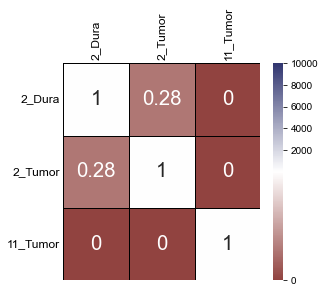

In [ ]:
fig, ax = plt.subplots ( nrows = 1, ncols = 1, figsize =(4.5, 4.5))

colors = [ "#914340", "white", "#313670"]
positions = [0, 0.5, 1]  # Define the positions for each color
cmap = LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))

cmap = LinearSegmentedColormap.from_list("custom_red_blue", colors, N=256)
# 2. 0~1은 빨간색 계열, 1~10000은 파란색 계열로 지정
norm = TwoSlopeNorm(vmin=0, vcenter=1, vmax=10000)



fig.subplots_adjust ( wspace = 0.4, bottom = 0.03, top = 0.7, left = 0.22, right = 0.98)
fig.set_facecolor('white')

sns.heatmap ( df , cmap = cmap, norm = norm, linewidths = 0.5, linecolor = "black", annot = df, annot_kws={"size": 35 / np.sqrt(len( df))} )   # fmt=".2f", 
#fig.suptitle ( title, fontsize = 12, fontweight = "bold", ha = "left", x = 0 )
ax.set_xticklabels( [ i.get_text().replace( Sample_ID + "_" , "" ) for i in ax.get_xticklabels()],  ha = 'center', rotation = 90 )
ax.tick_params(axis = 'x',  pad = -0.5)
ax.set_yticklabels( [ i.get_text().replace( Sample_ID + "_" , "" ) for i in ax.get_yticklabels()], va = 'center' )
ax.tick_params(axis = 'y', pad = -0.5 )

plt.tick_params(axis='both', which='major', labelsize = 12, left = False, labelbottom = False, bottom=False, top = False, labeltop=True)


fig.savefig ( "/data/project/Meningioma/04.mutect/11.MeTel/" + str ( Sample_ID ) + "/02.Output/heatmap.pdf", dpi = 300)
fig.savefig ( "/data/project/Meningioma/script/03.Variant_calling_Annotation/MeTel.heatmap.pdf", dpi = 300)